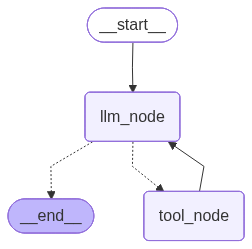

2026-07-13 11:40:04.437 | INFO     | __main__:wrap_tool_call:77 - 工具调用之前
2026-07-13 11:40:04.439 | INFO     | __main__:get_weather:30 - 网络波动,请重试
2026-07-13 11:40:04.439 | INFO     | __main__:wrap_tool_call:85 - 工具调用失败,当前调用次数:1,调用次数上限:3,异常信息:网络波动异常
2026-07-13 11:40:04.439 | INFO     | __main__:wrap_tool_call:77 - 工具调用之前
2026-07-13 11:40:04.440 | INFO     | __main__:get_weather:30 - 网络波动,请重试
2026-07-13 11:40:04.441 | INFO     | __main__:wrap_tool_call:85 - 工具调用失败,当前调用次数:2,调用次数上限:3,异常信息:网络波动异常
2026-07-13 11:40:04.441 | INFO     | __main__:wrap_tool_call:77 - 工具调用之前
2026-07-13 11:40:04.442 | INFO     | __main__:wrap_tool_call:81 - 工具调用之后


{'messages': [HumanMessage(content='今天北京的天气怎么样?', additional_kwargs={}, response_metadata={}, id='4a5305d9-f59a-481f-bb40-e3006878ed23'), AIMessage(content='好的，我来查一下今天北京的天气情况。', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 54, 'prompt_tokens': 284, 'total_tokens': 338, 'completion_tokens_details': None, 'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 256}, 'prompt_cache_hit_tokens': 256, 'prompt_cache_miss_tokens': 28}, 'model_provider': 'deepseek', 'model_name': 'deepseek-v4-flash', 'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402', 'id': 'b40a492d-307b-45ef-9d89-d504bebacb04', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019f598f-7bc5-7422-8baa-179d80fa4307-0', tool_calls=[{'name': 'get_weather', 'args': {'city': '北京'}, 'id': 'call_00_QSllJaAbZqAUcd7AWI7b2813', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 284, 'output_tokens': 54, 'total_tokens': 338, '

In [5]:
from dataclasses import dataclass
from typing import Literal

from dotenv import  load_dotenv
from langchain_deepseek import ChatDeepSeek
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.checkpoint.postgres import PostgresSaver
from langgraph.graph import MessagesState, StateGraph,START,END
from langchain.tools import tool
from langgraph.prebuilt import ToolNode
from loguru import logger
from langchain.messages import HumanMessage,ToolMessage

import random

load_dotenv(override = True)


@tool(parse_docstring=True)
def get_weather(city:str)->str:
    """
    查询指定城市的当日天气

    Args:
        city:城市名称
    """
    # 70%概率出现调用失败
    rand_int = random.randint(1,10)
    if rand_int < 8:
        logger.info("网络波动,请重试")
        raise ConnectionError("网络波动异常")
    return f"{city}天气晴朗,微风"

tools = [get_weather]

model = ChatDeepSeek(
    model = "deepseek-v4-flash",
    extra_body=
    {
        "thinking":{
            "type":"disabled"
        }
    }
)

model_with_tool = model.bind_tools(tools=tools)

#1. 设置最大重试次数
@dataclass
class UserContext:
    max_attempts:int

# 直接使用Messages作为状态
#2. 定义llm节点
def llm_node(state:MessagesState) -> MessagesState:
    messages = state["messages"]
    res = model_with_tool.invoke(messages)
    return {
        "messages":[res]
    }
#3. 定义路由 执行完llm_node之后判断是否需要进行工具调用
def router(state:MessagesState) -> Literal["tool_node",END]:
    if state["messages"][-1].tool_calls:
        return "tool_node"
    return END

#4. 定义工具调用包装器
# request: 固定参数 => 可以调用runtime
# execute: 执行 => 执行工具调用
def wrap_tool_call(request,execute):
    max_attempts = request.runtime.context.max_attempts
    tool_call_id = request.runtime.tool_call_id
    tool_msg = ""
    for i in range(max_attempts):
        try:
            # 工具调用之前:
            logger.info("工具调用之前")
            # 表示一次工具调用
            tool_msg = execute(request)
            # 工具调用之后
            logger.info("工具调用之后")
            # 执行成功
            break
        except ConnectionError as e:
            logger.info("工具调用失败,当前调用次数:{},调用次数上限:{},异常信息:{}",i+1,max_attempts,e)
    if not tool_msg:
        tool_msg = ToolMessage(
            tool_call_id = tool_call_id,
            content="调用次数达到上限,调用失败"
        )
    return tool_msg

#5. 构建图
builder = StateGraph(state_schema=MessagesState,context_schema=UserContext)
builder.add_node("llm_node",llm_node)
builder.add_node("tool_node",ToolNode(tools=tools,wrap_tool_call=wrap_tool_call))
builder.add_edge(START,"llm_node")
builder.add_conditional_edges("llm_node",router,path_map=["tool_node",END])
builder.add_edge("tool_node","llm_node")

graph = builder.compile()

from IPython.display import display
display(graph)

#6. 执行
res = graph.invoke({"messages":[HumanMessage(content="今天北京的天气怎么样?")]},context=UserContext(max_attempts=3))

print(res)
for msg in res["messages"]:
    msg.pretty_print()

